In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

In [14]:
class my_Callback(tf.keras.callbacks.LambdaCallback):
    def on_epoch_end(self, epoch, logs):
        if logs.get("accuracy") > 0.98:
            print("\nReached 98% accuracy so cancelling training!")
            self.model.stop_training = True


callbacks = my_Callback()
fmnist = tf.keras.datasets.fashion_mnist

In [3]:
(x_train, y_train), (x_test, y_test) = fmnist.load_data()

Label:  6
Image: 
 [[  0   0   0   0   1   0   0   0   0   0   0 152 192 135 134 165 209  25   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0  68 178 253 230 234 243 244 231 223 254 207  92   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0 208 239 232 219 217 218 210 207 210 212 216 226 234 212  31   0   1   0   0   0   0]
 [  0   0   0   0   1   0 104 234 210 214 216 219 211 224 228 225 209 214 214 206 223 212   0   0   0   0   0   0]
 [  0   0   0   0   0   0 205 217 216 212 216 218 212 222 217 219 210 215 211 208 208 230 100   0   0   0   0   0]
 [  0   0   0   0   0 198 233 213 219 211 216 217 212 227 215 220 213 214 209 206 209 224 225  22   0   0   0   0]
 [  0   0   0   0  63 244 223 222 212 212 216 220 213 222 214 217 209 213 211 208 214 226 249 173   0   0   0   0]
 [  0   0   0   0   0 175 231 231 207 214 212 212 213 223 218 216 205 209 208 203 224 238 210   0   0   0   0   0]
 [  0   0   0   0   0  35 236 241 209 210 211 210 210 224 217

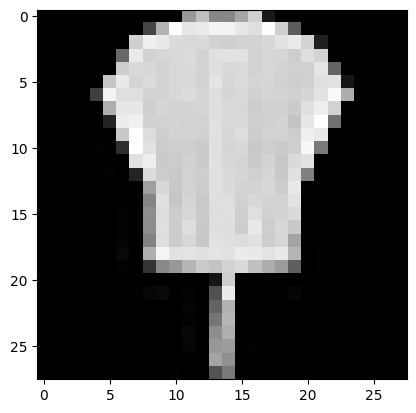

In [4]:
# You can put between 0 to 59999 here
index = 56

# Set number of characters per row when printing
np.set_printoptions(linewidth=320)

print("Label: ", y_train[index])
print("Image: \n", x_train[index])

plt.imshow(x_train[index], cmap="gray")
plt.show()

In [5]:
x_train = x_train / 255.0
x_test = x_test / 255.0

In [ ]:
model = tf.keras.Sequential([
    # CNN Model
    tf.keras.layers.Flatten(input_shape=(28, 28)),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dense(256, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax"),
])


model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

c:\Users\Uman\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [7]:
model.fit(x_train, y_train, epochs=100, callbacks=[callbacks])

Epoch 1/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8298 - loss: 0.4784
Epoch 2/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8678 - loss: 0.3611
Epoch 3/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8800 - loss: 0.3245
Epoch 4/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8882 - loss: 0.3025
Epoch 5/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8930 - loss: 0.2831
Epoch 6/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8983 - loss: 0.2704
Epoch 7/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9031 - loss: 0.2582
Epoch 8/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9074 - loss: 0.2464
Epoch 9/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9092 - loss: 0.2372
Epoch 10/100
1864/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9125 - loss: 0.2257
Reached 95% accuracy so cancelling training!
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9126 - 

In [8]:
model.evaluate(x_test, y_test)  

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8831 - loss: 0.3508


[0.350750595331192, 0.8830999732017517]

In [9]:
classification = model.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [11]:
cnn_model = tf.keras.Sequential([
    tf.keras.layers.InputLayer(input_shape=(28, 28, 1)),
    tf.keras.layers.Conv2D(32, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax"),
])


c:\Users\Uman\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


In [12]:
cnn_model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

In [15]:
cnn_model.fit(x_train, y_train, epochs=100, callbacks=[callbacks])

Epoch 1/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.8697 - loss: 0.3638
Epoch 2/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.9027 - loss: 0.2671
Epoch 3/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.9172 - loss: 0.2249
Epoch 4/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.9293 - loss: 0.1917
Epoch 5/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.9395 - loss: 0.1639
Epoch 6/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.9469 - loss: 0.1421
Epoch 7/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.9546 - loss: 0.1221
Epoch 8/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.9610 - loss: 0.1052
Epoch 9/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - accuracy: 0.9678 - loss: 0.0884
Epoch 10/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.9715 - loss: 0.0779
Epoch 11/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - accuracy: 0.9758 - loss: 0.06

In [16]:
model.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8831 - loss: 0.3508


[0.350750595331192, 0.8830999732017517]

In [ ]:
model.predict(x_test)
# model prediction

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


array([[3.5951150e-05, 2.1010552e-05, 3.3476915e-06, ..., 2.0103849e-01, 2.3204763e-07, 7.9785305e-01],
       [8.0977870e-06, 5.9916354e-15, 9.9931085e-01, ..., 1.0338514e-17, 1.0963025e-11, 2.4696119e-16],
       [1.9008182e-15, 1.0000000e+00, 5.7864245e-18, ..., 1.3340583e-33, 2.0936247e-20, 3.4349757e-28],
       ...,
       [4.2924806e-04, 1.0797698e-11, 1.0889518e-03, ..., 2.8972515e-11, 9.9686509e-01, 2.1639838e-12],
       [1.5301547e-12, 1.0000000e+00, 8.6424157e-13, ..., 1.3292115e-19, 1.4174743e-12, 1.0431680e-17],
       [1.3185651e-05, 2.5743196e-08, 6.5143649e-05, ..., 1.8073816e-04, 1.9918916e-05, 8.4257852e-07]], dtype=float32)